In [1]:
import numpy as np
import matplotlib.pyplot as plt

def divided_difference_table(x, y):

    n = len(x)

    table = np.zeros((n, n))

    # Zeroth-order divided differences
    table[:, 0] = y

    # Higher-order divided differences
    for j in range(1, n):
        for i in range(n - j):

            table[i, j] = (
                table[i + 1, j - 1] - table[i, j - 1]
            ) / (x[i + j] - x[i])

    return table


def newton_coefficients(table):

    return table[0, :]


def newton_interpolation(x_data, coefficients, x):

    n = len(coefficients)

    result = coefficients[n - 1]

    for i in range(n - 2, -1, -1):

        result = coefficients[i] + (
            x - x_data[i]
        ) * result

    return result

x_all = np.array([
    -1.00,
    -0.92,
    -0.75,
    -0.61,
    -0.48,
    -0.31,
    -0.17,
     0.02,
     0.15,
     0.29,
     0.43,
     0.58,
     0.67,
     0.81,
     0.93,
     1.00
])

# Function values
y_all = np.exp(x_all)


x_eval = np.linspace(-1, 1, 500)

exact_values = np.exp(x_eval)


number_of_points = [4, 8, 12, 16]

results = []

for num_points in number_of_points:

    x_data = x_all[:num_points]
    y_data = y_all[:num_points]

    table = divided_difference_table(
        x_data,
        y_data
    )

    coefficients = newton_coefficients(table)

    interpolated_values = np.array([
        newton_interpolation(
            x_data,
            coefficients,
            point
        )
        for point in x_eval
    ])

    error = np.abs(
        exact_values - interpolated_values
    )

    max_error_index = np.argmax(error)

    max_error = error[max_error_index]

    max_error_x = x_eval[max_error_index]

    degree = num_points - 1

    results.append([
        num_points,
        degree,
        max_error,
        max_error_x
    ])



print("Interpolation Accuracy Comparison")
print("----------------------------------")

print(
    "Points\tDegree\tMaximum Error\tLocation"
)

for result in results:

    print(
        f"{result[0]}\t"
        f"{result[1]}\t"
        f"{result[2]:.10e}\t"
        f"{result[3]:.6f}"
    )

Interpolation Accuracy Comparison
----------------------------------
Points	Degree	Maximum Error	Location
4	3	3.0046021417e-01	1.000000
8	7	4.2437931709e-04	1.000000
12	11	6.4115321941e-09	1.000000
16	15	8.8817841970e-16	0.891784


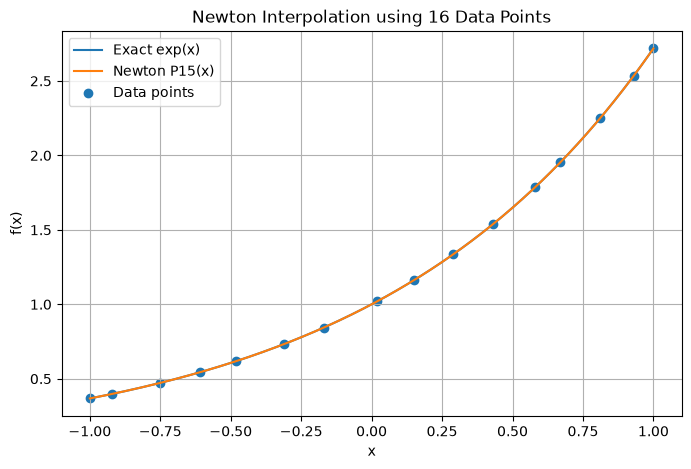

In [2]:
# ---------------------------------------------------------
# Function comparison: all 16 points
# ---------------------------------------------------------

x_data = x_all
y_data = y_all

table = divided_difference_table(
    x_data,
    y_data
)

coefficients = newton_coefficients(table)

p15_values = np.array([
    newton_interpolation(
        x_data,
        coefficients,
        point
    )
    for point in x_eval
])


plt.figure(figsize=(8, 5))

plt.plot(
    x_eval,
    exact_values,
    label="Exact exp(x)"
)

plt.plot(
    x_eval,
    p15_values,
    label="Newton P15(x)"
)

plt.scatter(
    x_all,
    y_all,
    label="Data points"
)

plt.xlabel("x")
plt.ylabel("f(x)")

plt.title(
    "Newton Interpolation using 16 Data Points"
)

plt.legend()
plt.grid(True)

plt.show()

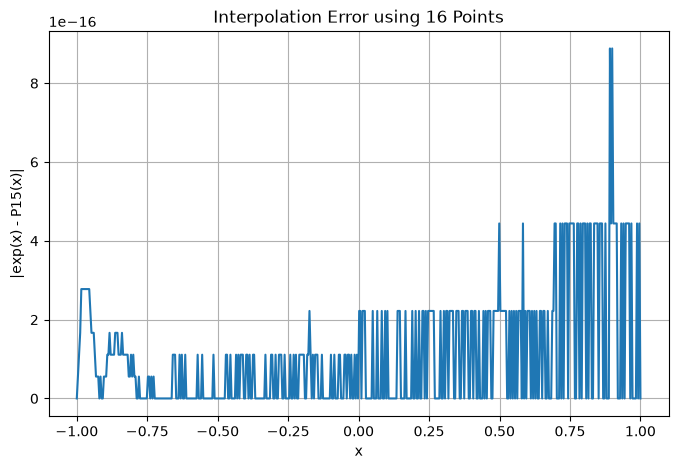

In [3]:
# ---------------------------------------------------------
# Error plot for P15
# ---------------------------------------------------------

error_p15 = np.abs(
    exact_values - p15_values
)

plt.figure(figsize=(8, 5))

plt.plot(
    x_eval,
    error_p15
)

plt.xlabel("x")

plt.ylabel(
    "|exp(x) - P15(x)|"
)

plt.title(
    "Interpolation Error using 16 Points"
)

plt.grid(True)

plt.show()

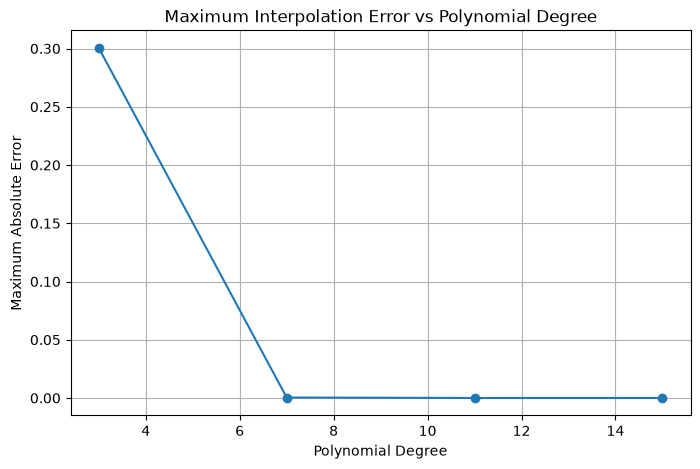

In [4]:
# ---------------------------------------------------------
# Maximum error vs polynomial degree
# ---------------------------------------------------------

degrees = [
    result[1]
    for result in results
]

maximum_errors = [
    result[2]
    for result in results
]


plt.figure(figsize=(8, 5))

plt.plot(
    degrees,
    maximum_errors,
    marker="o"
)

plt.xlabel("Polynomial Degree")

plt.ylabel("Maximum Absolute Error")

plt.title(
    "Maximum Interpolation Error vs Polynomial Degree"
)

plt.grid(True)

plt.show()